<a href="https://colab.research.google.com/github/GDVevo/ml_uni/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%965_%D0%9B%D0%B8%D0%BD%D0%B5%D0%B9%D0%BD%D0%B0%D1%8F_%D0%B8_%D0%BB%D0%BE%D0%B3%D0%B8%D1%81%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%81%D0%B8%D1%8F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **Практическая работа №5. Линейная и логистическая регрессия**



## **Линейная регрессия**



### **Задание №1. Прогнозирование продаж автомобилей**

- **Шаг 1**: Загрузите набор данных о продажах автомобилей, содержащий информацию о цене, возрасте, пробеге и других характеристиках.
  - **Совет №1**: Проверьте данные на наличие пропущенных значений и выбросов. Используйте `pandas` для обнаружения пропусков (`df.isnull().sum()`) и выбросов (например, с помощью метода межквартильного размаха - `df.boxplot()`).
  - **Совет №2**: Для пропущенных значений используйте стратегию заполнения средними значениями или медианой, чтобы минимизировать влияние на распределение данных (`df.fillna()`).




- Ссылка на набор данных: https://www.kaggle.com/datasets/gagandeep16/car-sales

In [ ]:
# Ваш код
import pandas as pd
import kagglehub
kagglehub.dataset_download("gagandeep16/car-sales")

Using Colab cache for faster access to the 'car-sales' dataset.


'/kaggle/input/car-sales'

Manufacturer            0
Model                   0
Sales_in_thousands      0
__year_resale_value    36
Vehicle_type            0
Price_in_thousands      2
Engine_size             1
Horsepower              1
Wheelbase               1
Width                   1
Length                  1
Curb_weight             2
Fuel_capacity           1
Fuel_efficiency         3
Latest_Launch           0
Power_perf_factor       2
dtype: int64


<Axes: >

,Sales_in_thousands,__year_resale_value,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,...,Model_Town car,Model_V40,Model_V70,Model_Villager,Model_Viper,Model_Voyager,Model_Windstar,Model_Wrangler,Model_Xterra,Vehicle_type_Passenger
0,16.919,16.360,21.500000,1.8,140.0,101.2,67.3,172.4,2.639,13.2,...,False,False,False,False,False,False,False,False,False,True
1,39.384,19.875,28.400000,3.2,225.0,108.1,70.3,192.9,3.517,17.2,...,False,False,False,False,False,False,False,False,False,True
2,14.114,18.225,27.390755,3.2,225.0,106.9,70.6,192.0,3.470,17.2,...,False,False,False,False,False,False,False,False,False,True
3,8.588,29.725,42.000000,3.5,210.0,114.6,71.4,196.6,3.850,18.0,...,False,False,False,False,False,False,False,False,False,True
4,20.397,22.255,23.990000,1.8,150.0,102.6,68.2,178.0,2.998,16.4,...,False,False,False,False,False,False,False,False,False,True


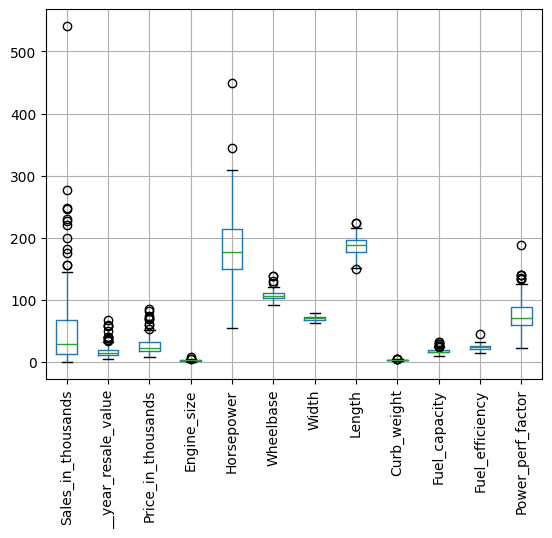

In [ ]:
df = pd.read_csv('/kaggle/input/car-sales/Car_sales.csv') # если вывел ошибку, запустить еще раз

print(df.isnull().sum())
display(df.boxplot(rot=90))
df2 = pd.get_dummies(df, columns=['Manufacturer', 'Latest_Launch', 'Model', 'Vehicle_type'], drop_first=True)

df2.fillna(df2.mean(), inplace=True)

df2.head()

- **Шаг 2**: Проведите предварительный анализ данных:
  - Постройте гистограммы для каждого числового признака, чтобы понять их распределение.
  - Постройте диаграммы рассеяния для выявления зависимостей между признаками и целевой переменной (ценой).
  - **Совет**: Используйте корреляционную матрицу для выявления сильных линейных зависимостей между признаками.

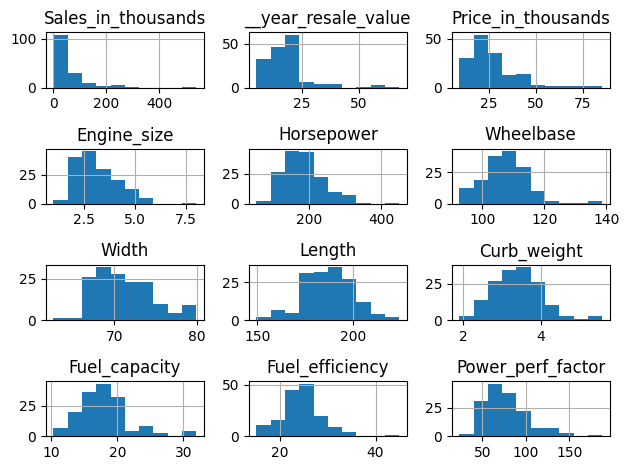

In [ ]:
# Ваш код
import matplotlib.pyplot as plt

df2.hist()
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:896: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="best")
/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:896: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="best")
/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:896: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="best")
/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:896: UserWarning: No artists with labels found to put in legend.  Note that artists whose label sta

IndexError: index 3 is out of bounds for axis 0 with size 3

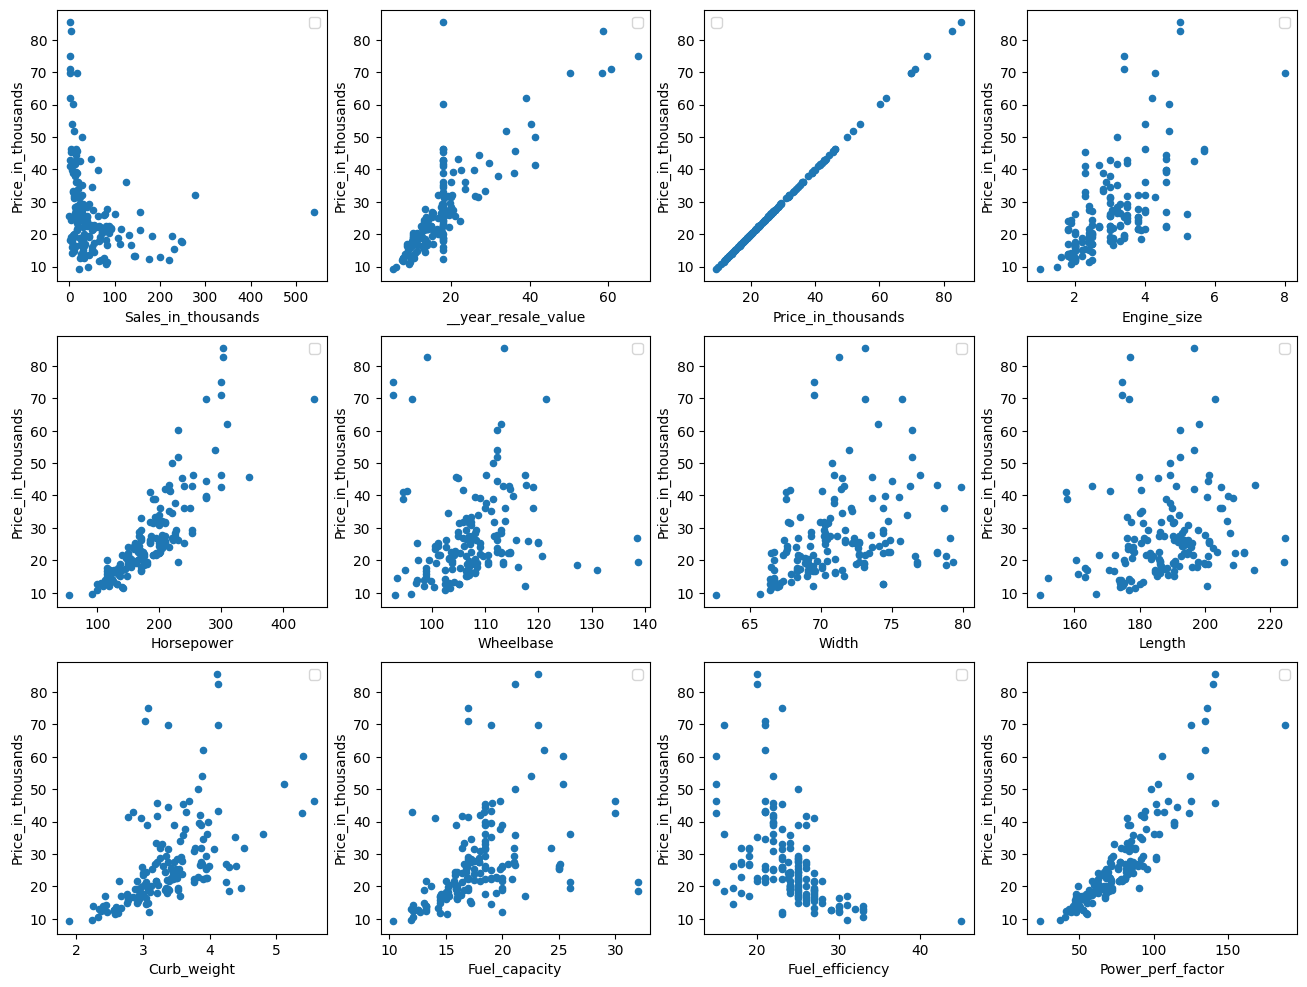

In [ ]:
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(16, 12))
for idx, feature in enumerate(df2.columns[:-1]):
     df2.plot(feature, "Price_in_thousands", subplots=True, kind="scatter", ax=axes[idx // 4, idx % 4])

- **Шаг 3**: Разделите данные на обучающую и тестовую выборки (например, 70% на обучение и 30% на тестирование) с помощью `train_test_split` из `sklearn.model_selection`.

In [ ]:
# Ваш код
from sklearn.model_selection import train_test_split
X = df2.drop('Price_in_thousands', axis=1)
y = df2['Price_in_thousands']

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.3,
                                                    random_state=42)
display(X_train.shape, X_test.shape)

(109, 325)

(48, 325)

- **Шаг 4**: Постройте и обучите модели линейной регрессии с различными типами регуляризации:
  - Обучите базовую модель `LinearRegression` (без регуляризации).
  - Обучите модель **Ridge** (L2-регуляризация) с подбором гиперпараметра `alpha` с помощью `GridSearchCV`.
  - Обучите модель **Lasso** (L1-регуляризация) с подбором гиперпараметра `alpha` с помощью `RandomizedSearchCV`.
  - Обучите модель **ElasticNet** (комбинация L1 и L2) с подбором гиперпараметров `alpha` и `l1_ratio` с помощью `GridSearchCV` и/или `RandomizedSearchCV`.
  - **Совет**: Используйте `np.logspace(-4, 4, 50)` для генерации сетки значений `alpha`.



In [ ]:
# Ваш код
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import numpy as np

model = LinearRegression()
ridge = Ridge(random_state=42)
lasso = Lasso(random_state=42)
elnet = ElasticNet(random_state=42)

# Параметры L1/L2
param_dist = {'alpha':np.logspace(-4, 4, 50)}
# Параметры ElasticNet
param_dist_elnet = {'alpha':np.logspace(-4, 4, 50), 'l1_ratio':np.linspace(0.001, 0.99, 20)}

grid_search = GridSearchCV(ridge, param_dist, cv=5, n_jobs=-1)
grid_search.fit(X, y)

rsearch_lasso = RandomizedSearchCV(lasso, param_distributions=param_dist,
                                   cv=5, n_jobs=-1, random_state=42)
rsearch_lasso.fit(X, y)

grid_search_elnet = GridSearchCV(elnet, param_dist_elnet, cv=5, n_jobs=-1)
grid_search_elnet.fit(X, y)

models = {
    'Linear Regression (без регуляризации)': LinearRegression(),
    'Ridge (L2)': grid_search.best_estimator_,
    'Lasso (L1)': rsearch_lasso.best_estimator_,
    'ElasticNet (L1 + L2)': grid_search_elnet.best_estimator_
}

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.333e+01, tolerance: 3.172e+00
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.342e+01, tolerance: 3.172e+00
  model = cd_fast.enet_coordinate_descent(


- **Шаг 5**: Оцените качество всех моделей с использованием метрик MSE, RMSE, MAE и R².
  - Выведите значения метрик для каждой модели и интерпретируйте их.


In [ ]:
# Ваш код
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

results = {}
predictions = {}

# Обучение и оценка каждой модели
for name, model in models.items():
    model.fit(X_train, y_train)
    # Предсказание
    y_pred = model.predict(X_test)

    # Метрики
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Сохранение результатов
    results[name] = {
        'MSE': mse,
        'RMSE': rmse,
        'MAE':mae,
        'R²': r2,
    }
    predictions[name] = (y_pred)

    print(f"\n{name}:")
    print(f"  MSE:  {mse:.4f}")
    print(f"  MSE:  {mse:.4f}")
    print(f"  MAE: {mae:.4f}")
    print(f"  R²:   {r2:.4f}")


Linear Regression (без регуляризации):
  MSE:  8.8630
  MSE:  8.8630
  MAE: 2.0399
  R²:   0.9691

Ridge (L2):
  MSE:  5.6537
  MSE:  5.6537
  MAE: 1.7006
  R²:   0.9803

Lasso (L1):
  MSE:  5.7785
  MSE:  5.7785
  MAE: 1.1550
  R²:   0.9798

ElasticNet (L1 + L2):
  MSE:  5.6103
  MSE:  5.6103
  MAE: 1.4076
  R²:   0.9804


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.304e+00, tolerance: 1.735e+00
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.173e+01, tolerance: 1.735e+00
  model = cd_fast.enet_coordinate_descent(


- **Шаг 6**: Визуализируйте результаты:
  - Постройте график зависимости предсказанных цен от фактических для каждой модели.



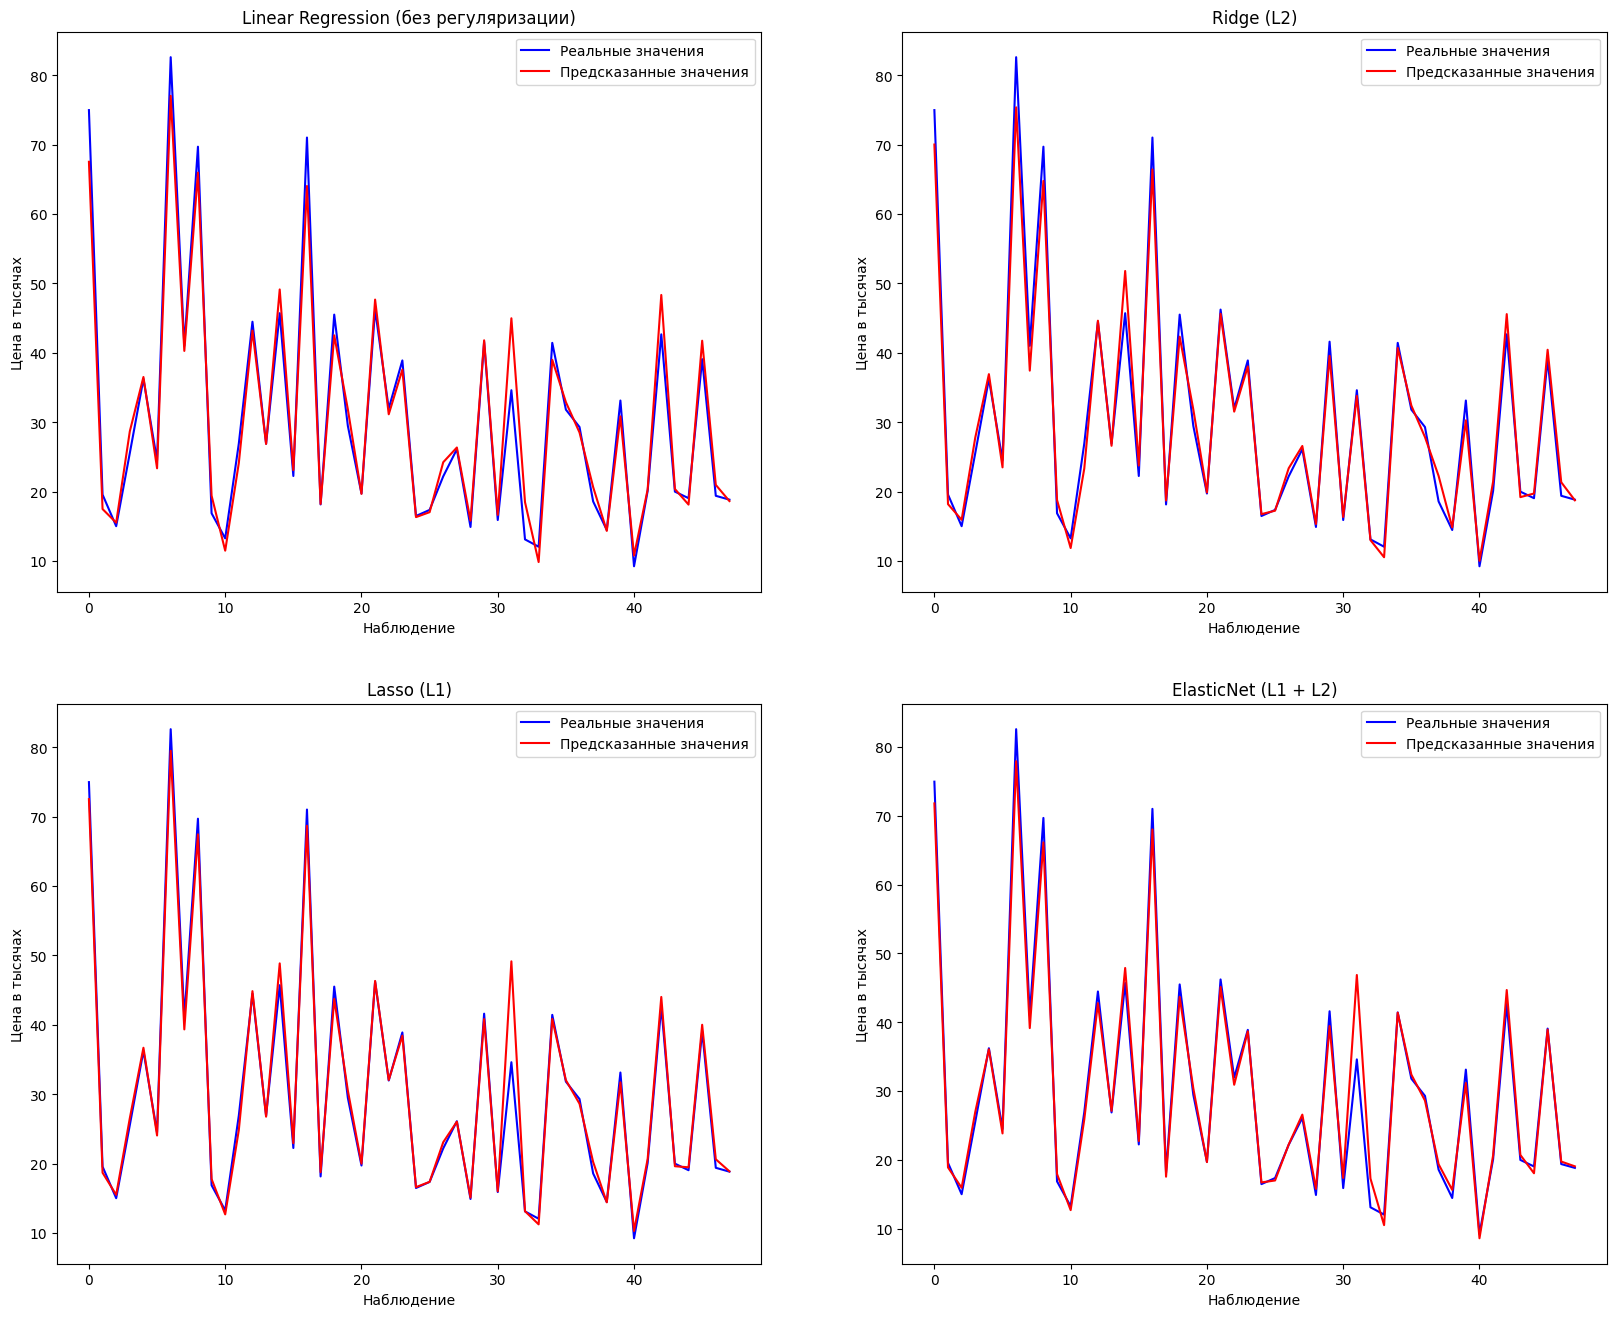

In [ ]:
# Ваш код
real = y_test.values

plt.figure(figsize=(20, 16))
n_rows = len(predictions)//2
n_cols = len(predictions) - n_rows

for ind, name in enumerate(predictions):
  plt.subplot(n_rows, n_cols, ind+1)
  plt.plot(real, label='Реальные значения', color='blue')
  plt.plot(predictions.get(name), label='Предсказанные значения', color='red')
  plt.title(name)
  plt.xlabel('Наблюдение')
  plt.ylabel('Цена в тысячах')
  plt.legend()



- **Шаг 7**: **Сравните все модели между собой по целевым метрикам (MSE, RMSE, MAE, R²)**:
  - Создайте сводную таблицу с метриками для всех моделей.
  - Определите лучшую модель и выведите для неё все метрики, а также оптимальные гиперпараметры.


In [ ]:
# Ваш код
import pandas as pd

df = pd.DataFrame.from_dict(results, orient='index').sort_values('R²',ascending=False)
display(df)
print(f'Лучшая модель: {df.iloc[0].name}')
print(f'Гиперпараметры данной модели: {models.get(df.iloc[0].name)}') # без .get_params(), т.к. то выводит ВСЕ гиперпараметры

,MSE,RMSE,MAE,R²
ElasticNet (L1 + L2),5.610326,2.368613,1.407633,0.980429
Ridge (L2),5.653679,2.377747,1.700587,0.980278
Lasso (L1),5.778458,2.403842,1.154966,0.979843
Linear Regression (без регуляризации),8.863044,2.977086,2.039871,0.969083


Лучшая модель: ElasticNet (L1 + L2)
Гиперпараметры данной модели: ElasticNet(alpha=np.float64(0.009102981779915217), l1_ratio=np.float64(0.99),
           random_state=42)


---



### **Задание №2. Влияние погодных условий на урожайность**




- **Шаг 1**: Загрузите набор данных о погодных условиях и урожайности сельскохозяйственных культур.
  - **Совет**: Проверьте данные на наличие пропущенных значений и выбросов. Используйте стратегию заполнения пропусков средними значениями или медианой.

- Ссылка на набор данных: https://www.kaggle.com/datasets/waqi786/climate-change-impact-on-agriculture


In [20]:
# Ваш код
import kagglehub

kagglehub.dataset_download("waqi786/climate-change-impact-on-agriculture")

Using Colab cache for faster access to the 'climate-change-impact-on-agriculture' dataset.


'/kaggle/input/climate-change-impact-on-agriculture'

Year                           0
Country                        0
Region                         0
Crop_Type                      0
Average_Temperature_C          0
Total_Precipitation_mm         0
CO2_Emissions_MT               0
Crop_Yield_MT_per_HA           0
Extreme_Weather_Events         0
Irrigation_Access_%            0
Pesticide_Use_KG_per_HA        0
Fertilizer_Use_KG_per_HA       0
Soil_Health_Index              0
Adaptation_Strategies          0
Economic_Impact_Million_USD    0
dtype: int64


,Year,Country,Region,Crop_Type,Average_Temperature_C,Total_Precipitation_mm,CO2_Emissions_MT,Crop_Yield_MT_per_HA,Extreme_Weather_Events,Irrigation_Access_%,Pesticide_Use_KG_per_HA,Fertilizer_Use_KG_per_HA,Soil_Health_Index,Adaptation_Strategies,Economic_Impact_Million_USD
0,2001,India,West Bengal,Corn,1.55,447.06,15.22,1.737,8,14.54,10.08,14.78,83.25,Water Management,808.13
1,2024,China,North,Corn,3.23,2913.57,29.82,1.737,8,11.05,33.06,23.25,54.02,Crop Rotation,616.22
2,2001,France,Ile-de-France,Wheat,21.11,1301.74,25.75,1.719,5,84.42,27.41,65.53,67.78,Water Management,796.96
3,2001,Canada,Prairies,Coffee,27.85,1154.36,13.91,3.890,5,94.06,14.38,87.58,91.39,No Adaptation,790.32
4,1998,India,Tamil Nadu,Sugarcane,2.19,1627.48,11.81,1.080,9,95.75,44.35,88.08,49.61,Crop Rotation,401.72


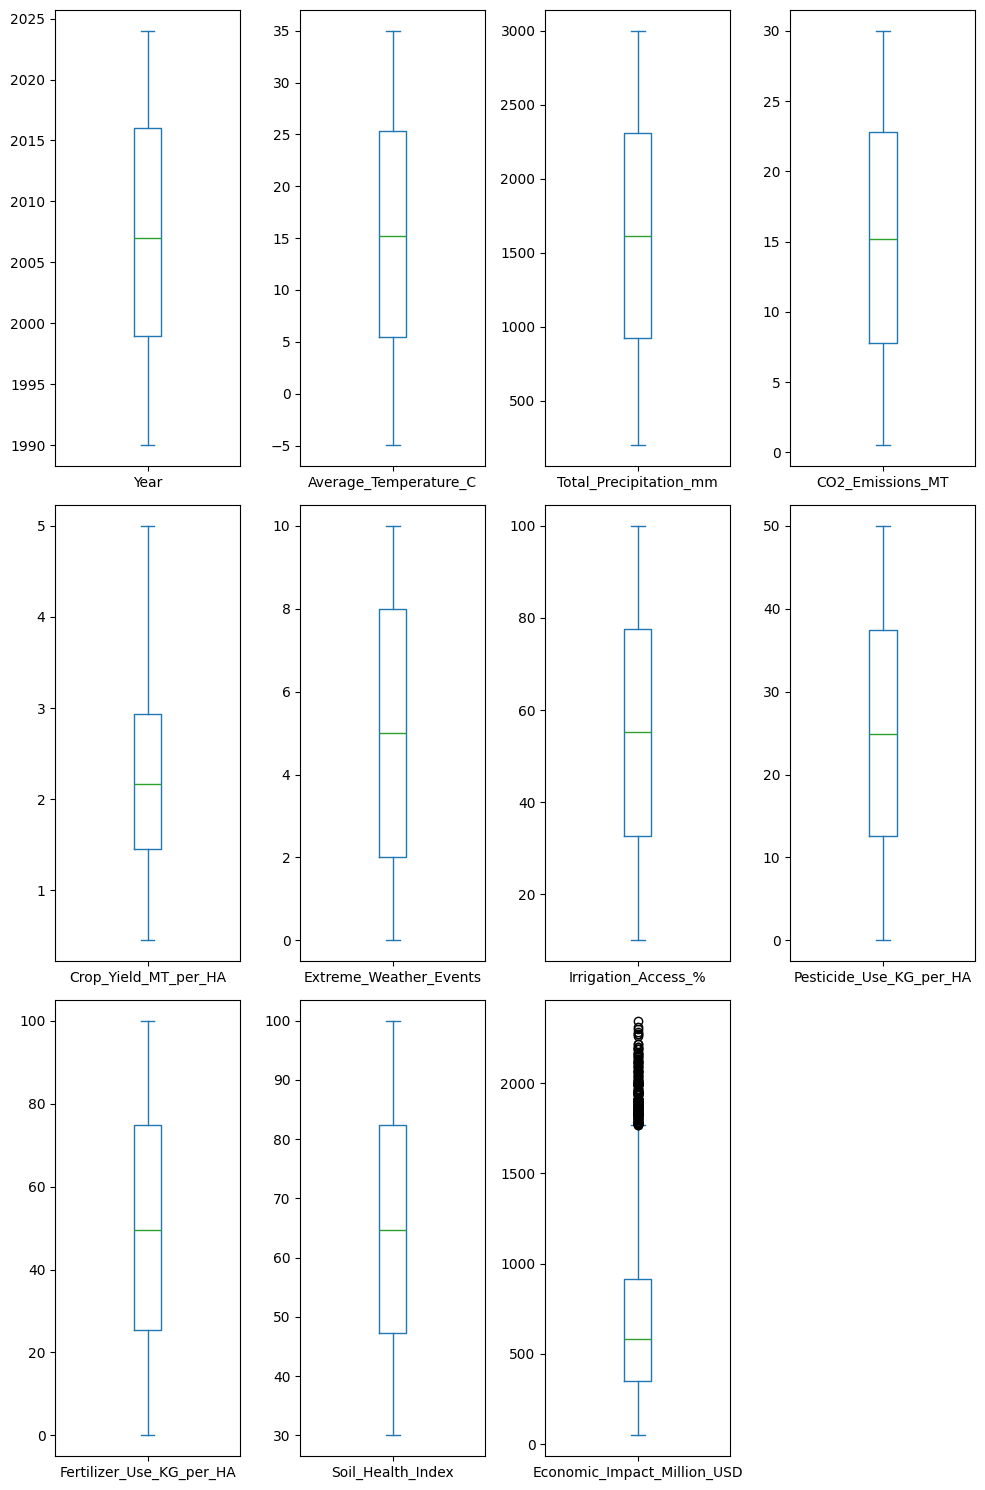

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/kaggle/input/climate-change-impact-on-agriculture/climate_change_impact_on_agriculture_2024.csv')
print(df.isnull().sum())

display(df.head())
df.plot(kind='box', subplots=True, layout=(3, 4), figsize=(10, 15))
df2 = pd.get_dummies(df, columns=['Country', 'Region', 'Crop_Type', 'Adaptation_Strategies'], drop_first=True)
plt.tight_layout()




- **Шаг 2**: Выполните анализ данных:
  - Постройте корреляционную матрицу для выявления зависимостей между признаками.
  - Постройте диаграммы рассеяния для ключевых признаков.
  - **Совет**: Удалите или преобразуйте признаки с низкой корреляцией с целевой переменной, чтобы улучшить модель.



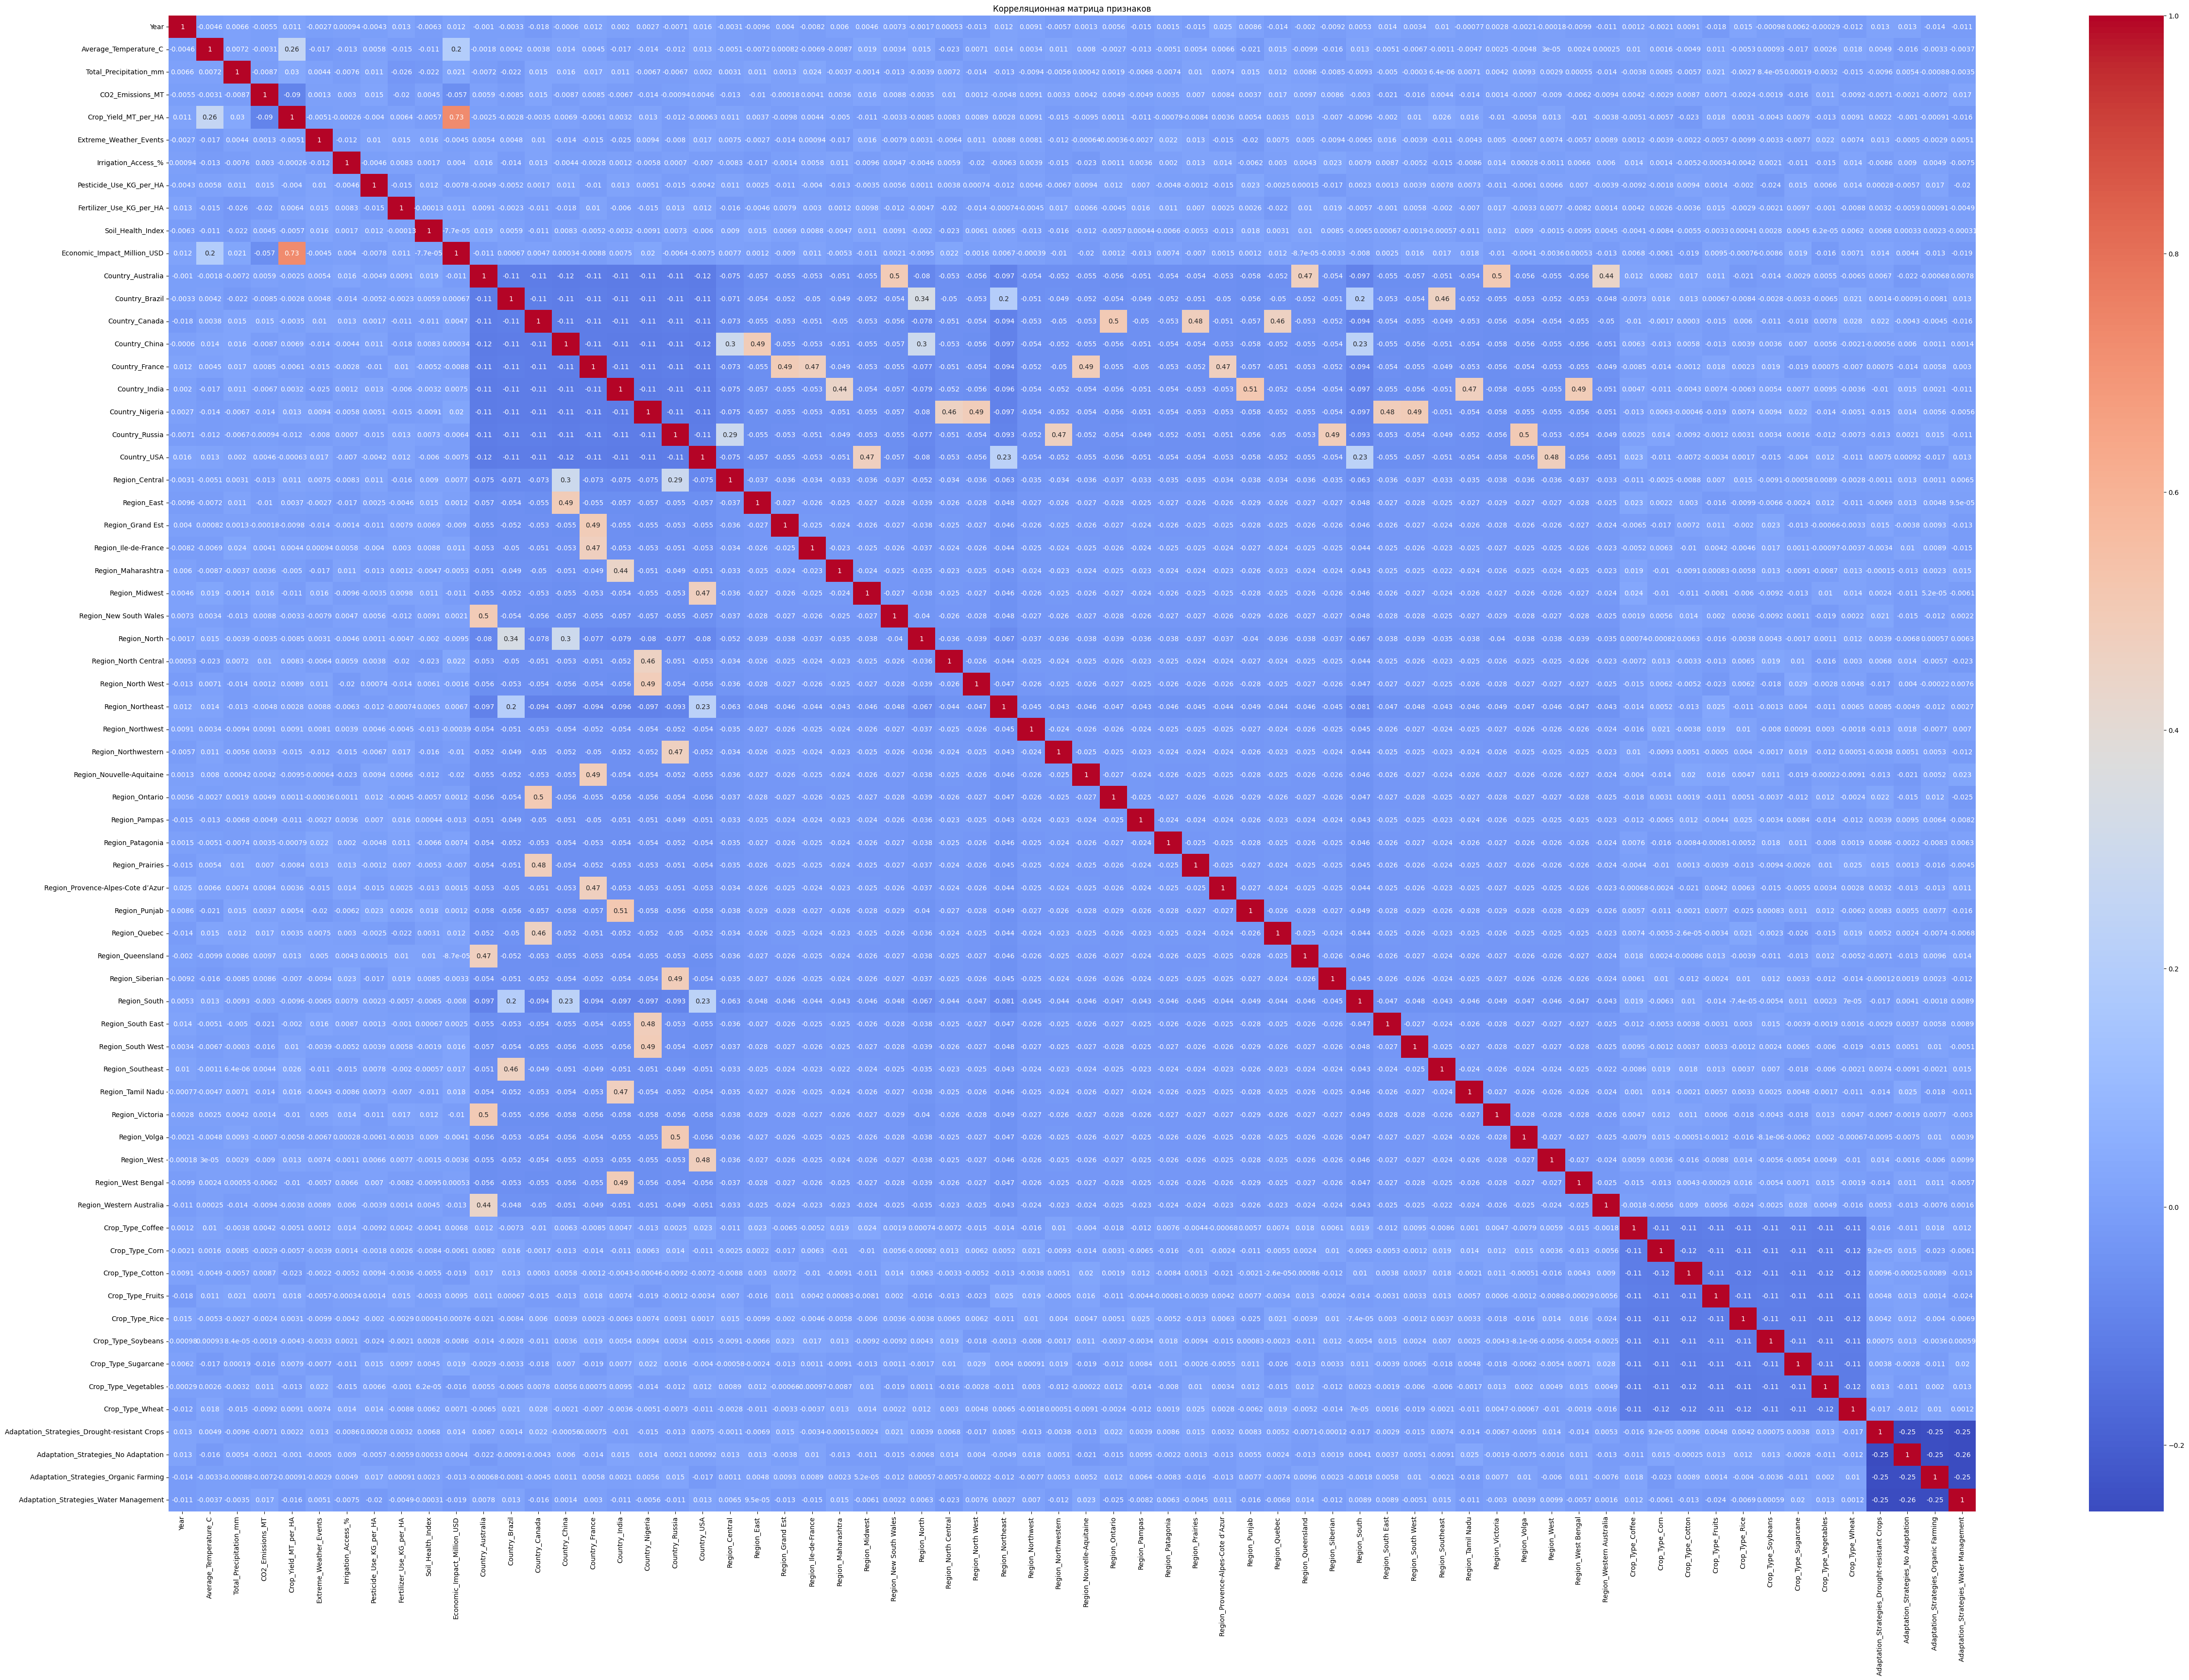

In [ ]:
# Ваш код
import seaborn as sns

corr_mat = df2.corr()
plt.figure(figsize=(60, 40))
sns.heatmap(corr_mat, annot=True, cmap='coolwarm')
plt.title('Корреляционная матрица признаков')
plt.show()

In [22]:
# По созданной матрице видим, что к признакам с низкой корреляцией можно отнести: Crop_Type, Adaptation_Strategies, Irrigation_Access_%, Country, Region
df3 = df.drop(['Irrigation_Access_%', 'Crop_Type', 'Adaptation_Strategies', "Country", "Region"], axis=1)
df3.head()

,Year,Average_Temperature_C,Total_Precipitation_mm,CO2_Emissions_MT,Crop_Yield_MT_per_HA,Extreme_Weather_Events,Pesticide_Use_KG_per_HA,Fertilizer_Use_KG_per_HA,Soil_Health_Index,Economic_Impact_Million_USD
0,2001,1.55,447.06,15.22,1.737,8,10.08,14.78,83.25,808.13
1,2024,3.23,2913.57,29.82,1.737,8,33.06,23.25,54.02,616.22
2,2001,21.11,1301.74,25.75,1.719,5,27.41,65.53,67.78,796.96
3,2001,27.85,1154.36,13.91,3.890,5,14.38,87.58,91.39,790.32
4,1998,2.19,1627.48,11.81,1.080,9,44.35,88.08,49.61,401.72


/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:896: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="best")
/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:896: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="best")
/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:896: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="best")
/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:896: UserWarning: No artists with labels found to put in legend.  Note that artists whose label sta

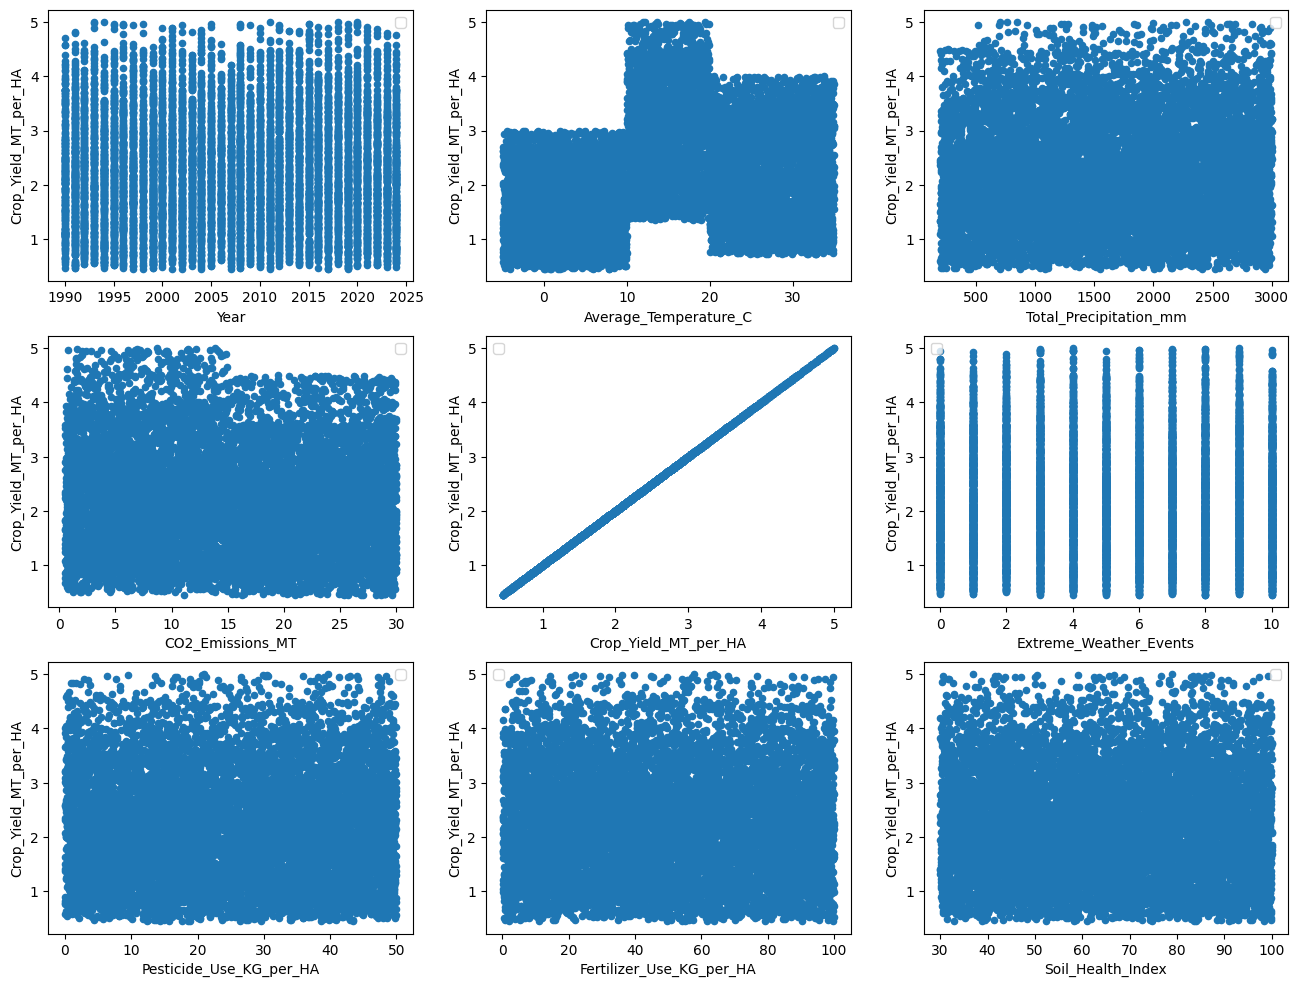

In [ ]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(16, 12))
for idx, feature in enumerate(df3.columns[:-1]):
     # Целевым признаком выбираем урожайность на гектар - Crop_Yield_MT_per_HA
     df3.plot(feature, "Crop_Yield_MT_per_HA", subplots=True, kind="scatter", ax=axes[idx // 3, idx % 3])

- **Шаг 3**: Разделите данные на обучающую и тестовую выборки.

In [28]:
# Ваш код
from sklearn.model_selection import train_test_split


#Уберем все признаки, не относящимся к погодным
df4 = df3.drop(['Year', 'Pesticide_Use_KG_per_HA', 'Fertilizer_Use_KG_per_HA', 'Soil_Health_Index', 'Economic_Impact_Million_USD'], axis=1)

X = df4.drop('Crop_Yield_MT_per_HA', axis=1)
y = df4['Crop_Yield_MT_per_HA']

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.3,
                                                    random_state=42)
display(X_train.shape, X_test.shape)
X_train.head()

(7000, 4)

(3000, 4)

,Average_Temperature_C,Total_Precipitation_mm,CO2_Emissions_MT,Extreme_Weather_Events
9069,3.63,890.92,15.29,1
2603,6.50,1954.63,13.23,4
7738,33.42,2523.44,5.64,4
1579,5.54,2409.73,19.04,9
5058,27.23,1896.43,15.32,3




- **Шаг 4**: Постройте и обучите модели линейной регрессии с различными типами регуляризации для оценки влияния температуры и уровня осадков на урожайность:
  - Обучите базовую модель `LinearRegression` (без регуляризации).
  - Обучите модель **Ridge** (L2-регуляризация) с подбором гиперпараметра `alpha` с помощью `RandomizedSearchCV`.
  - Обучите модель **Lasso** (L1-регуляризация) с подбором гиперпараметра `alpha` с помощью `GridSearchCV`.
  - Обучите модель **ElasticNet** с подбором гиперпараметров `alpha` и `l1_ratio` с помощью `GridSearchCV` и/или `RandomizedSearchCV` .

In [29]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import numpy as np

# время выполнения - ~30 сек.
model = LinearRegression()
ridge = Ridge(random_state=42)
lasso = Lasso(random_state=42)
elnet = ElasticNet(random_state=42)

# Параметры L1/L2
param_dist = {'alpha':np.logspace(-4, 4, 50)}
# Параметры ElasticNet
param_dist_elnet = {'alpha':np.logspace(-4, 4, 50), 'l1_ratio':np.linspace(0.001, 0.99, 20)}

grid_search = GridSearchCV(lasso, param_dist, cv=5, n_jobs=-1)
grid_search.fit(X, y)

rsearch_ridge = RandomizedSearchCV(ridge, param_distributions=param_dist,
                                   cv=5, n_jobs=-1, random_state=42)
rsearch_ridge.fit(X, y)

grid_search_elnet = GridSearchCV(elnet, param_dist_elnet, cv=5, n_jobs=-1)
grid_search_elnet.fit(X, y)

models = {
    'Linear Regression (без регуляризации)': model,
    'Ridge (L2)': rsearch_ridge.best_estimator_,
    'Lasso (L1)': grid_search.best_estimator_,
    'ElasticNet (L1 + L2)': grid_search_elnet.best_estimator_
}

- **Шаг 5**: Проведите оценку точности всех моделей.
  - Выведите значения метрик MSE, RMSE, MAE и R² для каждой модели и интерпретируйте их.

In [30]:
# Ваш код
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
results = {}
predictions = {}

# Обучение и оценка каждой модели
for name, model in models.items():
    model.fit(X_train, y_train)
    # Предсказание
    y_pred = model.predict(X_test)

    # Метрики
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Сохранение результатов
    results[name] = {
        'MSE': mse,
        'RMSE': rmse,
        'MAE':mae,
        'R²': r2,
    }
    predictions[name] = (y_pred)

    print(f"\n{name}:")
    print(f"  MSE:  {mse:.4f}")
    print(f"  MSE:  {mse:.4f}")
    print(f"  MAE: {mae:.4f}")
    print(f"  R²:   {r2:.4f}")


Linear Regression (без регуляризации):
  MSE:  0.9484
  MSE:  0.9484
  MAE: 0.7960
  R²:   0.0688

Ridge (L2):
  MSE:  0.9483
  MSE:  0.9483
  MAE: 0.7961
  R²:   0.0689

Lasso (L1):
  MSE:  0.9480
  MSE:  0.9480
  MAE: 0.7960
  R²:   0.0691

ElasticNet (L1 + L2):
  MSE:  0.9480
  MSE:  0.9480
  MAE: 0.7960
  R²:   0.0692




- **Шаг 6**: Визуализируйте данные и результаты моделей:
  - Постройте графики зависимости предсказанных значений от фактических для каждой модели.

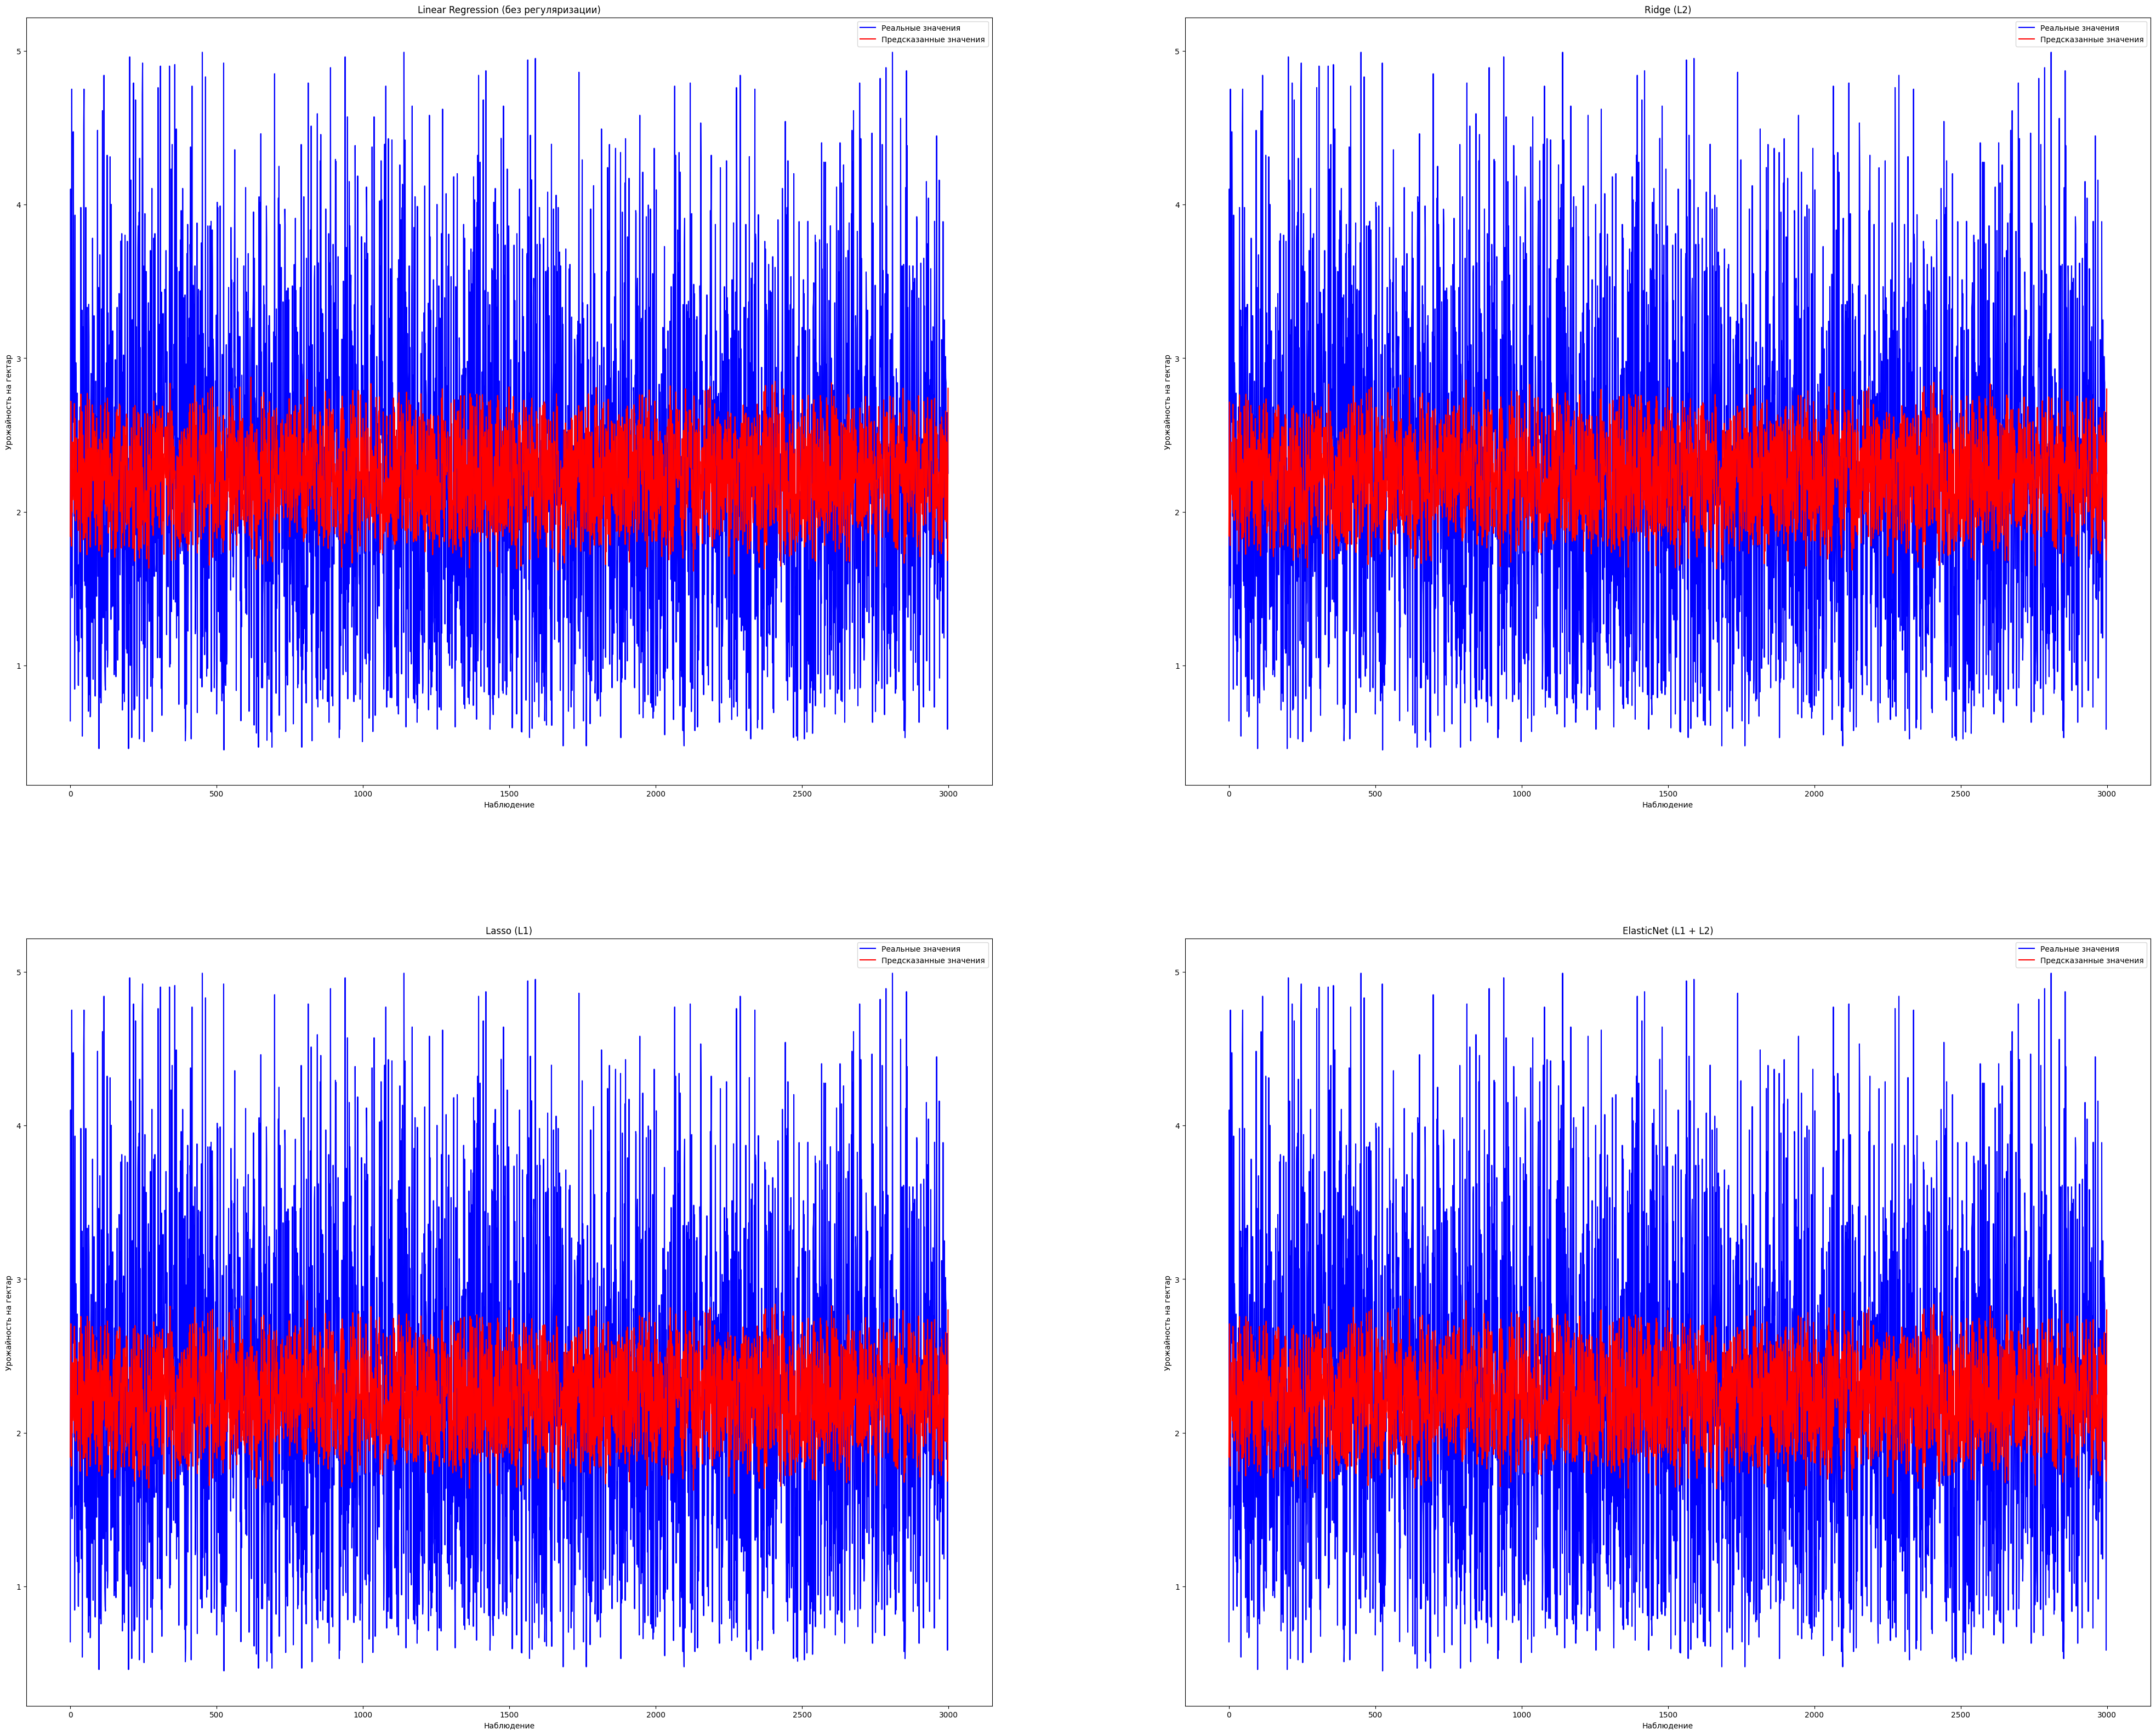

In [33]:
# Ваш код
real = y_test.values

plt.figure(figsize=(50, 40))
n_rows = len(predictions)//2
n_cols = len(predictions) - n_rows

for ind, name in enumerate(predictions):
  plt.subplot(n_rows, n_cols, ind+1)
  plt.plot(real, label='Реальные значения', color='blue')
  plt.plot(predictions.get(name), label='Предсказанные значения', color='red')
  plt.title(name)
  plt.xlabel('Наблюдение')
  plt.ylabel('Урожайность на гектар')
  plt.legend()

- **Шаг 7**: **Сравните все модели между собой по целевым метрикам (MSE, RMSE, MAE, R²)**:
  - Создайте сводную таблицу с метриками для всех моделей.
  - Определите лучшую модель и выведите для неё все метрики, а также оптимальные гиперпараметры.

In [34]:
# Ваш код
import pandas as pd

df = pd.DataFrame.from_dict(results, orient='index').sort_values('R²',ascending=False)
display(df)
best_model = models.get(df.iloc[0].name)
print(f'Лучшая модель: {df.iloc[0].name}')
print(f'Гиперпараметры данной модели: {best_model}')

,MSE,RMSE,MAE,R²
ElasticNet (L1 + L2),0.948007,0.973657,0.795994,0.069158
Lasso (L1),0.948028,0.973667,0.795996,0.069137
Ridge (L2),0.948306,0.973810,0.796083,0.068865
Linear Regression (без регуляризации),0.948405,0.973861,0.796040,0.068767


Лучшая модель: ElasticNet (L1 + L2)
Гиперпараметры данной модели: ElasticNet(alpha=np.float64(0.02811768697974228),
           l1_ratio=np.float64(0.7297368421052632), random_state=42)


- **Шаг 8: Проанализируйте влияние признаков на урожайность**

  - На основе лучшей модели проведите анализ важности признаков:

    - Извлеките коэффициенты (`coef_`) лучшей модели и сопоставьте их с названиями признаков.
    - Визуализируйте важность признаков с помощью горизонтальной столбчатой диаграммы.
    - Проинтерпретируйте результаты: определите, какие погодные факторы (температура, осадки, CO₂ и др.) оказывают наибольшее положительное и отрицательное влияние на урожайность.
    - **Совет**: Для модели Lasso обратите внимание на признаки с нулевыми коэффициентами — они были исключены как незначимые.
    - **Совет**: Если данные были стандартизированы (`StandardScaler`), коэффициенты можно напрямую сравнивать по абсолютной величине для оценки относительной важности.



ElasticNet(alpha=np.float64(0.02811768697974228),
           l1_ratio=np.float64(0.7297368421052632), random_state=42)
Average_Temperature_C: 0.023247
Total_Precipitation_mm: 0.000034
CO2_Emissions_MT: -0.009265
Extreme_Weather_Events: -0.001795


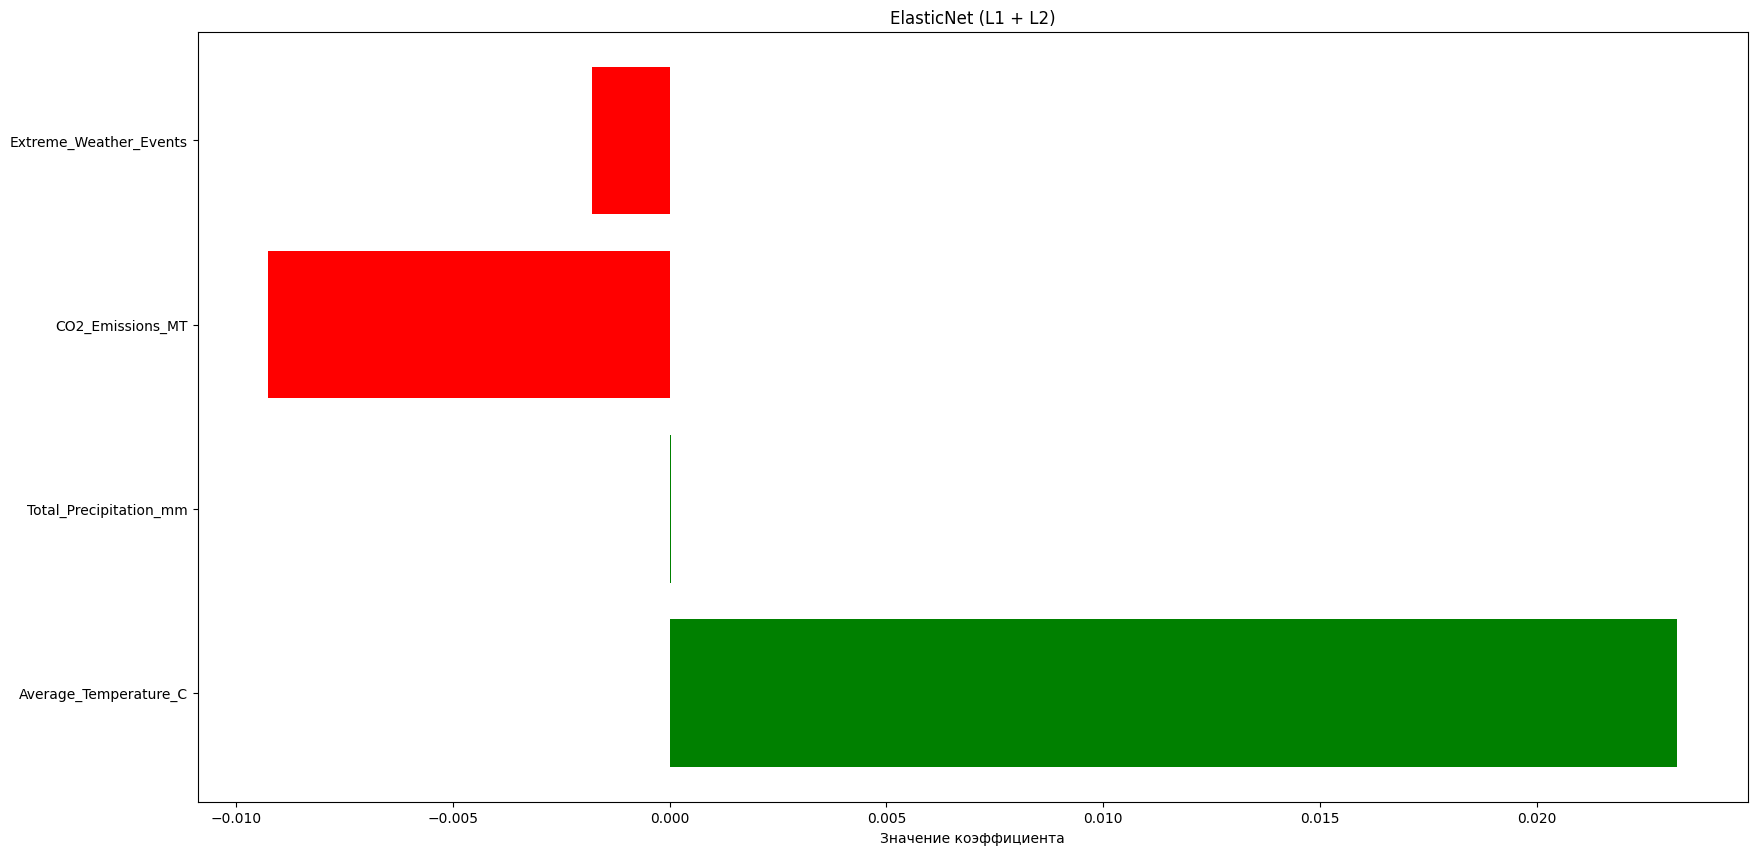

In [62]:
# Ваш код
import pandas as pd
coefs = []
cols = []
print(best_model)
for ind, value in enumerate(best_model.coef_):
  print(f"{X_test.columns[ind]}: {value:4f}")
  cols.append(X_test.columns[ind])
  coefs.append(value)

plt.figure(figsize=(20,10))
colors = ['green' if c > 0 else 'red' for c in coefs]
plt.barh(cols, coefs, color=colors)
plt.xlabel('Значение коэффициента')
plt.title(name)
plt.show()

#### **Интерпретация результатов (пример формулировки для отчёта):**



> На основе анализа коэффициентов лучшей модели установлено, что:
> - **Положительное влияние** на урожайность оказывают: Average_Temperature_C, Total_Precipitation_mm
> - **Отрицательное влияние** на урожайность оказывают: Extreme_Weather_Events, CO2_Emission_MT
> - Наиболее значимым фактором является Average_Temperature_C с коэффициентом 0.023247, что означает: при увеличении данного показателя на 1 единицу (при прочих равных) урожайность изменяется на 0.023247 единиц.

---



## **Логистическая регрессия**



### **Задание №3. Классификация клиентов банка**

- **Шаг 1**: Загрузите набор данных о клиентах банка, включающий данные о возрасте, доходе, кредитной истории и других характеристиках.
  - **Совет**: Проверьте данные на наличие пропущенных значений и выбросов. Используйте стратегию заполнения пропусков средними значениями или медианой.



- Ссылка на набор данных: https://www.kaggle.com/datasets/henriqueyamahata/bank-marketing/data

In [63]:
# Ваш код
import kagglehub

kagglehub.dataset_download("henriqueyamahata/bank-marketing")

Using Colab cache for faster access to the 'bank-marketing' dataset.


'/kaggle/input/bank-marketing'

In [69]:
import pandas as pd

df = pd.read_csv('/kaggle/input/bank-marketing/bank-additional-full.csv', sep = ';')
y = df['y'] # сразу выделяем y?
df = df.drop('y', axis=1)
print(df.isnull().sum())

display(df.head())
df.shape

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
dtype: int64


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0


(41188, 20)

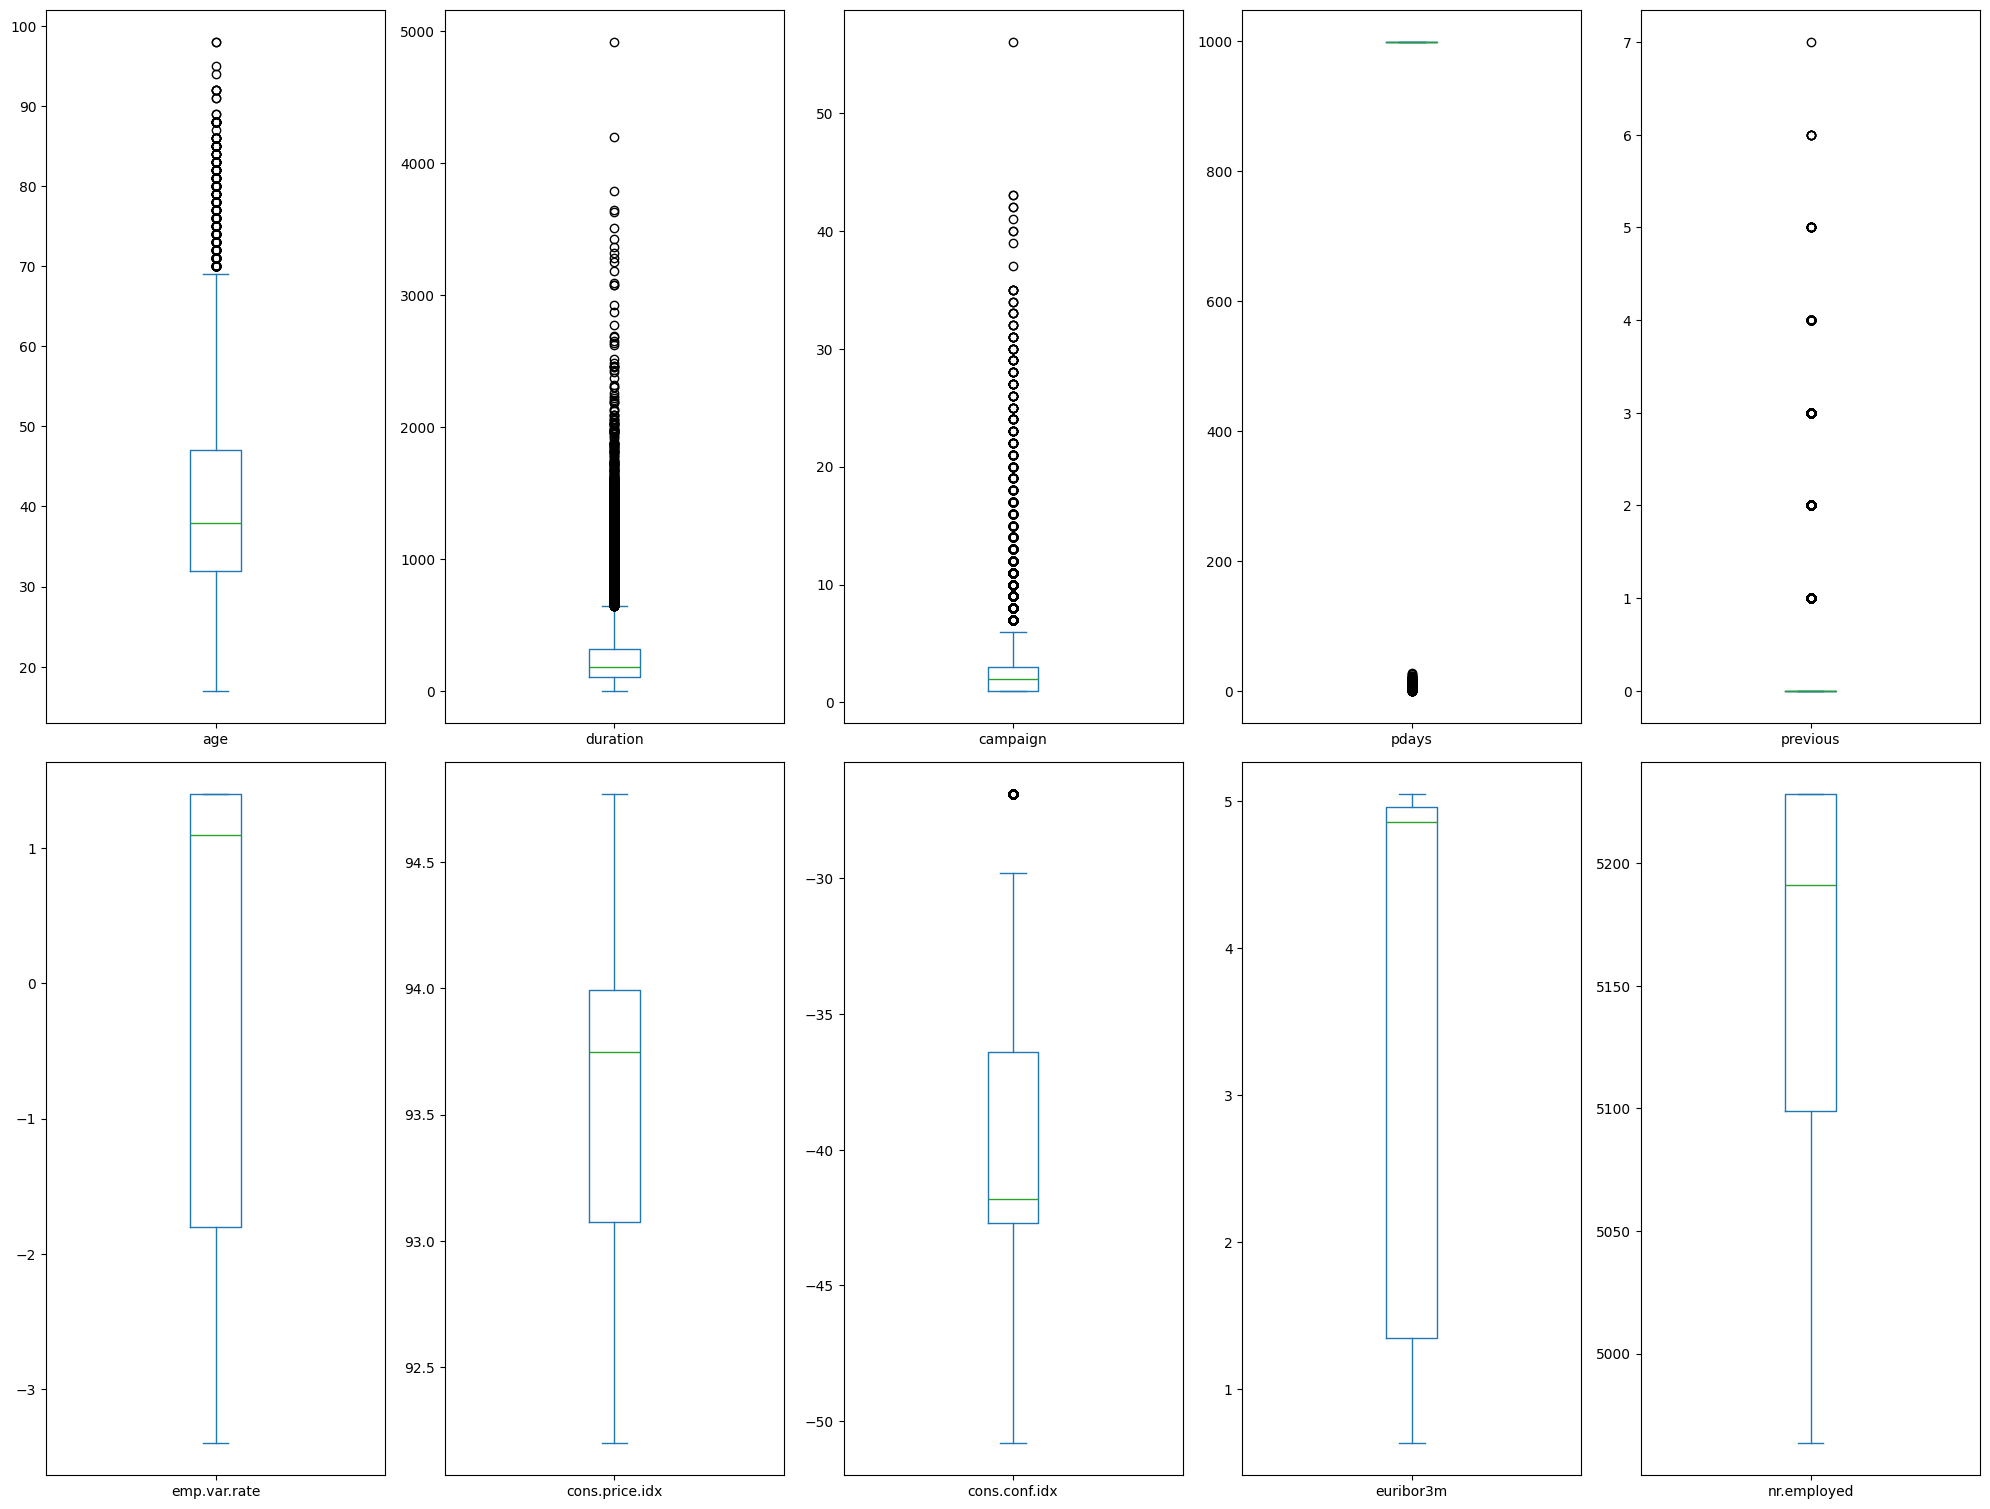

In [65]:
df.plot(kind='box', subplots=True, layout=(4, 5), figsize=(20, 30))
plt.tight_layout()

- **Шаг 2**: Проведите анализ данных и предобработку:
  - Закодируйте категориальные переменные с помощью `OneHotEncoder` или `pd.get_dummies`.
  - Нормализуйте числовые признаки с помощью `StandardScaler` для улучшения обучения модели.
  - **Совет**: Убедитесь, что все признаки имеют одинаковый масштаб, чтобы избежать доминирования одного признака над другими.

In [70]:
# Ваш код
from sklearn.preprocessing import StandardScaler

df2 = pd.get_dummies(df, columns=['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome'], drop_first=True)
scaler = StandardScaler().set_output(transform="pandas")
df2.head()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,56,261,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,True,False,False,False,True,False
1,57,149,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,True,False,False,False,True,False
2,37,226,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,True,False,False,False,True,False
3,40,151,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,True,False,False,False,True,False
4,56,307,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,True,False,False,False,True,False


- **Шаг 3**: Разделите данные на обучающую и тестовую выборки.

In [71]:
# Ваш код
from sklearn.model_selection import train_test_split

y = y.map({'no': 0, 'yes': 1})
X = df2.copy() # уже без целевого признака, см. ранее
# y был выделен ранее

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.3,
                                                    random_state=42)
display(X_train.shape, X_test.shape)

(28831, 53)

(12357, 53)

- **Шаг 4**: Постройте и обучите модели логистической регрессии с различными типами регуляризации для предсказания вероятности открытия депозитного счета клиентом:
  - Обучите модель `LogisticRegression` с **L2-регуляризацией** (`penalty='l2'`) и подбором гиперпараметра `C` с помощью `GridSearchCV`.
  - Обучите модель `LogisticRegression` с **L1-регуляризацией** (`penalty='l1'`, `solver='saga'`) и подбором гиперпараметра `C` с помощью `RandomizedSearchCV`.
  - Обучите модель `LogisticRegression` с **ElasticNet-регуляризацией** (`penalty='elasticnet'`, `solver='saga'`) и подбором гиперпараметров `C` и `l1_ratio` с помощью `GridSearchCV` и/или `RandomizedSearchCV` .
  - **Совет**: Для L1 и ElasticNet используйте `solver='saga'`, так как он поддерживает оба типа регуляризации.


In [106]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import numpy as np

# Ваш код
# время выполнения - ~8-9 мин.
model_l2 = LogisticRegression(penalty='l2')
model_l1 = LogisticRegression(penalty='l1', solver='saga')
elnet = LogisticRegression(penalty='elasticnet', solver='saga')

c_arr = np.linspace(0.001, 2, 10) # боялся что они могли замедлять работу, пока были в слова, поэтому перенес отдельно
l1_arr = np.linspace(0.001, 0.99, 20)
# Параметры L1/L2
param_dist = {'C': c_arr}
# Параметры ElasticNet
param_dist_elnet = {'C': c_arr, 'l1_ratio': l1_arr}

gsearch_l2 = GridSearchCV(model_l2, param_dist, cv=5, n_jobs=-1)
gsearch_l2.fit(X, y)
print('done l2') # проверка, что хотя бы прогресс идет
rsearch_l1 = RandomizedSearchCV(model_l1, param_dist, cv=5, n_jobs=-1,
                                random_state=42, n_iter=10)
rsearch_l1.fit(X, y)
print('done l1')
gsearch_elnet = RandomizedSearchCV(elnet, param_dist_elnet, cv=5, n_jobs=-1, n_iter=10)
gsearch_elnet.fit(X, y)
print('done elnet')
models = {
    'Logistic Regression (L2)': gsearch_l2.best_estimator_,
    'Logistic Regression (L1)': rsearch_l1.best_estimator_,
    'ElasticNet (L1 + L2)': gsearch_elnet.best_estimator_
}
print('done')

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


done l2


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


done l1
done elnet
done


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



- **Шаг 5**: Оцените качество всех моделей с использованием метрик точности (Accuracy), полноты (Recall), точности (Precision) и F1-меры.
  - Выведите значения метрик для каждой модели и интерпретируйте их. Обратите внимание на баланс между точностью и полнотой.
  - Постройте матрицу ошибок для каждой модели с помощью `confusion_matrix` и визуализируйте их с помощью `seaborn.heatmap`.

In [107]:
from sklearn.metrics import accuracy_score, precision_score, f1_score, recall_score

results = {}
predictions = {}
pred_proba = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)

    results[name] = {
        'Accuracy': acc,
        'Precision': prec,
        'F1': f1,
        'Recall': rec
    }
    predictions[name] = (y_pred)
    pred_proba[name] = (y_pred_proba)

    print(f"\n{name}:")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precison:  {prec:.4f}")
    print(f"  F1: {f1:.4f}")
    print(f"  Recall:   {rec:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Logistic Regression (L2):
  Accuracy:  0.9123
  Precison:  0.6862
  F1: 0.5091
  Recall:   0.4046


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



Logistic Regression (L1):
  Accuracy:  0.9070
  Precison:  0.6813
  F1: 0.4398
  Recall:   0.3247

ElasticNet (L1 + L2):
  Accuracy:  0.9071
  Precison:  0.6817
  F1: 0.4405
  Recall:   0.3254


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


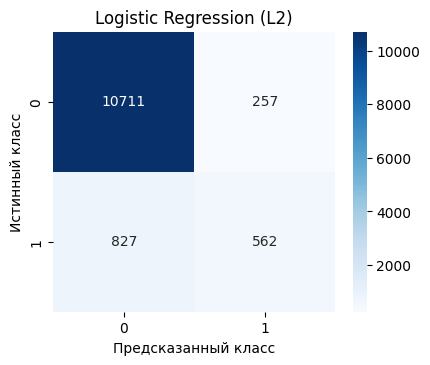

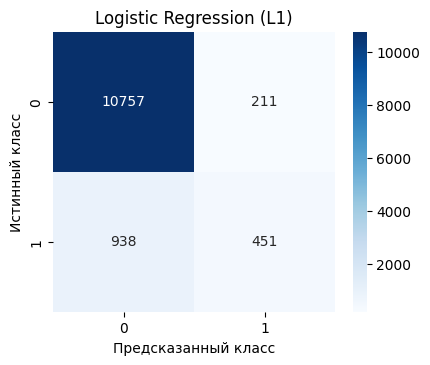

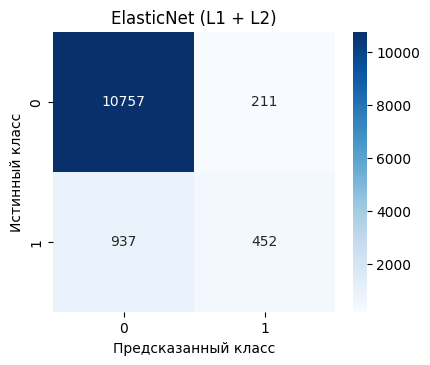

In [109]:
# Ваш код
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

real = y_test.values

n_rows = len(predictions)//2
n_cols = len(predictions) - n_rows
if n_rows ==  1:
  n_rows *= 2

for ind, name in enumerate(predictions):
  plt.figure(figsize=(10, 8))
  plt.subplot(n_rows, n_cols, ind+1)
  cm = confusion_matrix(y_test, predictions.get(name))
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
  plt.title(name)
  plt.xlabel('Предсказанный класс')
  plt.ylabel('Истинный класс')
  plt.show()

- **Шаг 6**: Визуализируйте ROC-кривые для всех моделей и вычислите AUC для оценки.
  - Используйте `roc_curve` и `auc` из `sklearn.metrics` для построения и расчёта.
  - Постройте все ROC-кривые на одном графике для наглядного сравнения.



AUC (Logistic Regression (L2)): 0.9257
AUC (Logistic Regression (L1)): 0.8808
AUC (ElasticNet (L1 + L2)): 0.8825


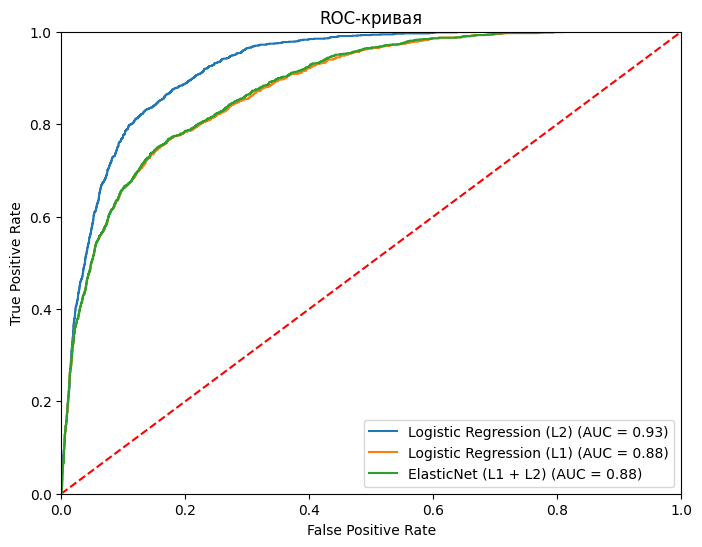

In [110]:
# Ваш код
from sklearn.metrics import roc_curve, auc
real = y_test.values
plt.figure(figsize=(8,6))
plt.plot([0,1], [0,1], 'r--')

for ind, name in enumerate(pred_proba):
  fpr, tpr, thresholds = roc_curve(y_test, pred_proba.get(name))
  auc_sc = auc(fpr, tpr)
  print(f'AUC ({name}): {auc_sc:.4f}')

  plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_sc:.2f})')
  plt.xlim([0,1])
  plt.ylim([0,1])
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
plt.title('ROC-кривая')
plt.legend(loc='lower right')
plt.show()

- **Шаг 7**: **Сравните все модели между собой по целевым метрикам (Accuracy, Precision, Recall, F1, AUC)**:
  - Создайте сводную таблицу с метриками для всех моделей.
  - Определите лучшую модель и выведите для неё все метрики, оптимальные гиперпараметры и матрицу ошибок.

,Accuracy,Precision,F1,Recall
Logistic Regression (L2),0.912276,0.686203,0.509058,0.404608
ElasticNet (L1 + L2),0.907097,0.681750,0.440546,0.325414
Logistic Regression (L1),0.907016,0.681269,0.439785,0.324694


Лучшая модель: Logistic Regression (L2)
Гиперпараметры данной модели: LogisticRegression(C=np.float64(0.001))


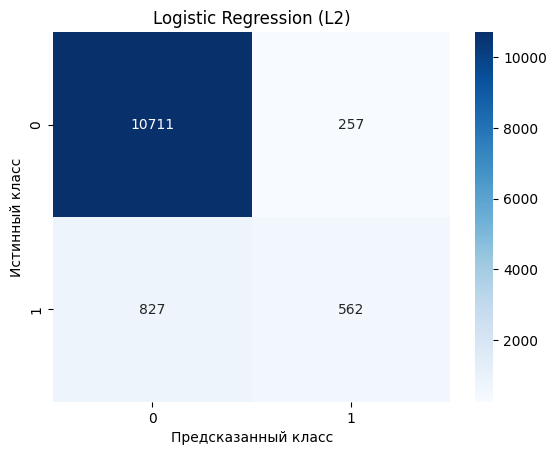

In [111]:
# Ваш код
import seaborn as sns
import pandas as pd

df = pd.DataFrame.from_dict(results, orient='index').sort_values('F1',ascending=False)
display(df)
best_model = models.get(df.iloc[0].name)
print(f'Лучшая модель: {df.iloc[0].name}')
print(f'Гиперпараметры данной модели: {best_model}')
cm = confusion_matrix(y_test, predictions.get(df.iloc[0].name))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(df.iloc[0].name)
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()